# Dataset 5 — Adult Census Income (UCI)

## Descripción general
Este dataset, conocido popularmente como "Census Income", es un estándar en la comunidad de Machine Learning. Contiene registros demográficos y laborales de la oficina del censo de EE. UU. de 1994. Es un dataset complejo debido a la alta cantidad de variables categóricas con muchas opciones (como ocupación y país de origen).

## Objetivo
**Problema de Clasificación Binaria** — Predecir si el ingreso anual de una persona supera los $50,000 dólares anuales (`income = 1`) o si es menor o igual (`income = 0`), basándose en un perfil demográfico y laboral.

## Estructura original
- **Filas iniciales:** 32,561 registros.
- **Columnas iniciales:** 15.
- **Variable objetivo:** `income` (Originalmente: `<=50K` y `>50K`).
- **Distribución inicial:** 76% (Bajos ingresos) vs 24% (Altos ingresos).

## Tratamiento aplicado y Justificaciones Técnicas

### 1. Limpieza de "Nulos Invisibles"
A diferencia de otros datasets, este utiliza el carácter `' ?'` para representar datos faltantes. 
- **Acción:** Se identificaron y reemplazaron por valores reales mediante **imputación por la moda** (para variables categóricas como `occupation`) y **mediana** (para variables numéricas). Esto evita perder miles de registros por filas incompletas.

### 2. Eliminación de Redundancia y Ruido (Feature Selection)
- **`education` vs `education-num`**: Se eliminó la columna de texto `education`, ya que el dataset ya proporciona una versión numérica codificada (`education-num`). Mantener ambas introduciría multicolinealidad.
- **`fnlwgt`**: Se eliminó esta columna por ser un peso estadístico del censo que no describe una característica intrínseca de la persona, sino cómo fue muestreada, careciendo de valor predictivo individual.

### 3. Codificación de Variables (Encoding)
- La variable objetivo se mapeó manualmente a formato binario ($0$ y $1$).
- El resto de variables categóricas (estado civil, raza, sexo, etc.) se transformaron mediante **One-Hot Encoding**. Esto expandió el dataset a 91 variables predictoras, permitiendo que el algoritmo procese matemáticamente categorías de texto.

### 4. Balanceo de Clases (Undersampling)
El dataset original presentaba un sesgo masivo hacia la clase de bajos ingresos. 
- **Decisión:** Se aplicó **Undersampling aleatorio** reduciendo la clase mayoritaria hasta igualar la cantidad de la minoritaria ($7,841$ registros cada una). 
- **Justificación:** Sin este paso, el modelo tendría una alta precisión global simplemente prediciendo "0" siempre, fallando en el objetivo real del negocio: identificar a las personas de altos ingresos.

### 5. Preparación Matemática para el Descenso de Gradiente
- **División 80/20:** Se reservó un 20% de los datos ($3,137$ registros) para la evaluación final, asegurando que el modelo se pruebe con datos que no "memorizó" durante el entrenamiento.
- **Normalización (Z-Score):** Se estandarizaron las características para que variables como `age` o `capital-gain` (con rangos muy distintos) tengan el mismo peso matemático. Se usó la media ($\mu$) y desviación ($\sigma$) del conjunto de entrenamiento para evitar el *Data Leakage*.
- **Término de Sesgo (Bias):** Se añadió una columna de unos al inicio de las matrices $X$ para representar el parámetro $\theta_0$.

## Resultado final
| Métrica | Valor |
|--|---------|
| Filas finales (Balanceadas) | 15,682 |
| Columnas (con bias) | 92 |
| Distribución de clases | 50.0% / 50.0% |
| Valores faltantes | 0 |

## ¿Está balanceado?
**Sí.** Como se observa en las gráficas de barras y pastel generadas, el dataset se encuentra perfectamente equilibrado. Este balanceo es crítico para modelos de clasificación, permitiendo que la frontera de decisión del algoritmo sea justa y no se sesgue hacia la clase que tenía más ejemplos originalmente.

Shape original: (32561, 15)

Variable objetivo - income (Distribución original):
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Shape después de eliminar columnas redundantes/inútiles: (32561, 13)

Columnas eliminadas por tener >50% de NaN:
  Ninguna columna superó el 50% de nulos.

NaN restantes: 0
Shape después de one-hot encoding: (32561, 92)

Balanceando las clases (Undersampling)...
Distribución después del balanceo:
income
1    7841
0    7841
Name: count, dtype: int64

=== DESCRIPCIÓN DEL DATASET PREPARADO ===
Nombre: Adult Census Income
Problema: Clasificación Binaria
Filas listas: 15682
Columnas totales: 92

Dataset guardado como 'Adult_preparado.csv'

 INICIANDO DIVISIÓN 80/20 Y NORMALIZACIÓN 
Tamaño X_train_norm: (12545, 92)
Tamaño y_train:      (12545,)
Tamaño X_test_norm:  (3137, 92)


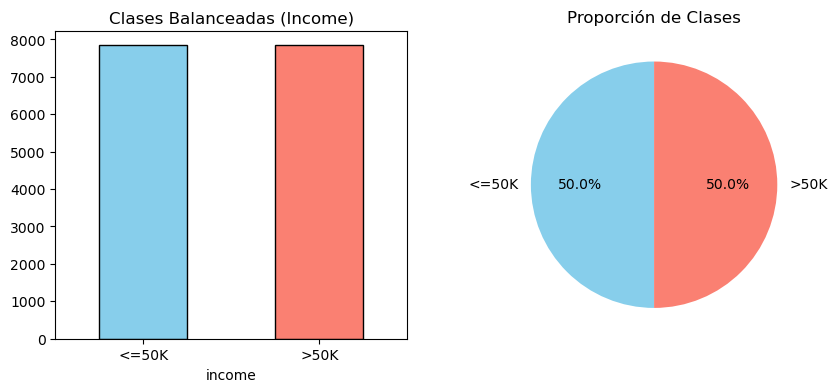

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PREPARACIÓN DATASET 5: Adult Census (Clasificación)

# 1. CARGAR
ruta_adult = r"C:\Users\Usuario\Documents\7mo semestre\Sis420\PrimerParcial\Dataset5\adult\adult.data"

# Definimos los nombres de las columnas (sacados de adult.names)
columnas = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 
            'marital-status', 'occupation', 'relationship', 'race', 'sex', 
            'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

# Cargamos indicando que ' ?' es un valor nulo real
df = pd.read_csv(ruta_adult, names=columnas, na_values=' ?', skipinitialspace=True)

print("Shape original:", df.shape)
print("\nVariable objetivo - income (Distribución original):")
print(df['income'].value_counts())

# 2. ELIMINAR COLUMNAS INÚTILES
# - fnlwgt: es un peso demográfico técnico, no sirve para predecir.
# - education: ya tenemos education-num que es la misma info en números.
df = df.drop(columns=['fnlwgt', 'education'])
print("\nShape después de eliminar columnas redundantes/inútiles:", df.shape)

# 3. ELIMINAR COLUMNAS CON >50% DE NaN
umbral = 0.5 * len(df)
cols_muchos_nulos = df.columns[df.isnull().sum() > umbral].tolist()
print("\nColumnas eliminadas por tener >50% de NaN:")
if cols_muchos_nulos:
    for col in cols_muchos_nulos:
        pct = df[col].isnull().sum() / len(df) * 100
        print(f"  {col}: {pct:.1f}% nulos")
else:
    print("  Ninguna columna superó el 50% de nulos.")
df = df.drop(columns=cols_muchos_nulos)

# 4. IMPUTAR NaN RESTANTES
cols_numericas = df.select_dtypes(include=['int64', 'float64']).columns
for col in cols_numericas:
    if df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)

cols_texto = df.select_dtypes(include='object').columns
for col in cols_texto:
    if col == 'income': continue 
    if df[col].isnull().sum() > 0:
        # Imputamos texto con la moda (valor más frecuente)
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nNaN restantes:", df.isnull().sum().sum())

# 5. ONE-HOT ENCODING
# Convertimos la meta a 0 y 1 (<=50K es 0, >50K es 1)
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

# Aplicamos One-Hot Encoding a las variables de entrada
df = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns.tolist())
print("Shape después de one-hot encoding:", df.shape)

# 6. BALANCEAR CLASES (Undersampling)
print("\nBalanceando las clases (Undersampling)...")
clase_mayoritaria = df[df['income'] == 0]
clase_minoritaria = df[df['income'] == 1]

# Igualamos la cantidad de registros de ambas clases
clase_mayoritaria_reducida = clase_mayoritaria.sample(n=len(clase_minoritaria), random_state=42)
df = pd.concat([clase_mayoritaria_reducida, clase_minoritaria])

# Mezclamos aleatoriamente
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("Distribución después del balanceo:")
print(df['income'].value_counts())

# 7. MOVER TARGET AL FINAL
cols = [c for c in df.columns if c != 'income'] + ['income']
df = df[cols]

# 8. RESUMEN FINAL
print("\n=== DESCRIPCIÓN DEL DATASET PREPARADO ===")
print(f"Nombre: Adult Census Income")
print(f"Problema: Clasificación Binaria")
print(f"Filas listas: {df.shape[0]}")
print(f"Columnas totales: {df.shape[1]}")

# 9. GUARDAR
df.to_csv('Adult_preparado.csv', index=False)
print("\nDataset guardado como 'Adult_preparado.csv'")

# =========================================================
# 10. DIVISIÓN 80/20 Y NORMALIZACIÓN MATEMÁTICA
# =========================================================
print("\n INICIANDO DIVISIÓN 80/20 Y NORMALIZACIÓN ")

# .astype(float) evita errores con tipos booleanos del One-Hot Encoding
X = df.drop('income', axis=1).astype(float).values
y = df['income'].values

m = len(y)
limite = int(m * 0.8)

# División 80/20
X_train, X_test = X[:limite], X[limite:]
y_train, y_test = y[:limite], y[limite:]

# Función manual para Normalizar
def normalizar(X_data):
    mu = np.mean(X_data, axis=0)
    sigma = np.std(X_data, axis=0)
    sigma[sigma == 0] = 1 
    X_norm = (X_data - mu) / sigma
    return X_norm, mu, sigma

X_train_norm, mu, sigma = normalizar(X_train)
X_test_norm = (X_test - mu) / sigma

# Agregar columna de unos (sesgo)
X_train_norm = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_norm = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print(f"Tamaño X_train_norm: {X_train_norm.shape}")
print(f"Tamaño y_train:      {y_train.shape}")
print(f"Tamaño X_test_norm:  {X_test_norm.shape}")

# 11. GRÁFICAS
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['income'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'], edgecolor='black')
plt.title("Clases Balanceadas (Income)")
plt.xticks([0, 1], ['<=50K', '>50K'], rotation=0)

plt.subplot(1, 2, 2)
plt.pie(df['income'].value_counts(), labels=['<=50K', '>50K'], autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90)
plt.title("Proporción de Clases")
plt.show()